# Two-Stage Town Recommender: K-Means Clustering + Supervised Classification

**Objective:** Build a proper recommender that matches buyer preferences to Singapore HDB towns.

## Why Two Stages?

A single 26-class classifier struggles because many towns are nearly identical by building
features alone (e.g. Sengkang vs Punggol, Jurong East vs Jurong West). Grouping towns into
meaningful clusters first reduces noise and aligns the model with how buyers actually think —
by neighbourhood character, not individual town name.

**Stage 1 — K-Means (unsupervised):** Aggregate each town's median property characteristics
into a profile. Cluster 26 town profiles into ~5 market segments.

**Stage 2 — Supervised classifier:** Label every transaction with its town's cluster.
Train LGBM (and comparison models) to predict cluster from buyer-interpretable features.
At inference the model returns a cluster → the app returns all towns within that cluster.

---

---

## Step 1: Imports and Constants

In [1]:
import time
import json
import warnings
import joblib
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

try:
    from lightgbm import LGBMClassifier
except ImportError:
    LGBMClassifier = None
    print("LightGBM not available — skipping")

try:
    from xgboost import XGBClassifier
except ImportError:
    XGBClassifier = None
    print("XGBoost not available — skipping")

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("CatBoost not available — skipping")

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')

# ── Reproducibility & hyperparameter constants ─────────────────────────────
RANDOM_STATE = 42
TEST_SIZE    = 0.25
N_ESTIMATORS = 300

---

## Step 2: Load Dataset

In [2]:
df = pd.read_csv('../data.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Towns ({df['town'].nunique()}): {sorted(df['town'].unique())}")
df.head(2)

C:\Users\jared\AppData\Local\Temp\ipykernel_21496\1640935162.py:1: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data.csv')


Shape: 270,619 rows × 76 columns
Towns (26): ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT BATOK', 'BUKIT MERAH', 'BUKIT PANJANG', 'BUKIT TIMAH', 'CENTRAL AREA', 'CHOA CHU KANG', 'CLEMENTI', 'GEYLANG', 'HOUGANG', 'JURONG EAST', 'JURONG WEST', 'KALLANG/WHAMPOA', 'MARINE PARADE', 'PASIR RIS', 'PUNGGOL', 'QUEENSTOWN', 'SEMBAWANG', 'SENGKANG', 'SERANGOON', 'TAMPINES', 'TOA PAYOH', 'WOODLANDS', 'YISHUN']


,Tranc_YearMonth,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,...,vacancy,pri_sch_affiliation,pri_sch_latitude,pri_sch_longitude,sec_sch_nearest_dist,sec_sch_name,cutoff_point,affiliation,sec_sch_latitude,sec_sch_longitude
0,2012-03,ANG MO KIO,5 ROOM,101,ANG MO KIO AVE 3,06 TO 10,117.0,Standard,1978,515000.0,...,61.0,0.0,1.369092,103.839041,474.789674,Ang Mo Kio Secondary School,224.0,0.0,1.367359,103.842600
1,2012-03,ANG MO KIO,3 ROOM,103,ANG MO KIO AVE 3,06 TO 10,73.0,New Generation,1978,368000.0,...,61.0,0.0,1.369092,103.839041,522.935557,Mayflower Secondary School,219.0,0.0,1.368337,103.835439


---

## Step 3: Feature Engineering

Helper functions and derived columns — sources noted per feature.

In [3]:
# ── distance_from_cbd (source: EDA_sprint.ipynb, Regression_Models_Comparison v2.ipynb) ──
def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in km between two lat/lon points."""
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi  = np.radians(lat2 - lat1)
    delta_lam  = np.radians(lon2 - lon1)
    a = (
        np.sin(delta_phi / 2) ** 2
        + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lam / 2) ** 2
    )
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

CBD_LAT, CBD_LON = 1.2897, 103.8501  # Raffles Place
df['distance_from_cbd'] = haversine(
    df['Latitude'], df['Longitude'], CBD_LAT, CBD_LON
)

# ── storey_ratio (source: manyu_-_Classification_Models_Comparison.ipynb) ──
# mid_storey / max_floor_lvl — how high up the unit sits relative to the block
mid_storey_num = pd.to_numeric(df['mid_storey'], errors='coerce')
max_floor_safe = pd.to_numeric(df['max_floor_lvl'], errors='coerce').replace(0, np.nan)
df['storey_ratio'] = (mid_storey_num / max_floor_safe).fillna(0)

# ── estate_height_modernity ───────────────────────────────────────────────
# Interaction term: max_floor_lvl / (hdb_age + 1)
# Disambiguates tall-new (Punggol ~4.4) from tall-old (Queenstown ~0.8) and
# short-old (Toa Payoh ~0.3) estates — solves the problem where both Punggol and
# Queenstown have tall blocks but belong to very different cluster types.
# Reconstructible at inference from existing form inputs (max_floor_lvl, hdb_age).
_max_floor = pd.to_numeric(df['max_floor_lvl'], errors='coerce').fillna(0)
_hdb_age   = pd.to_numeric(df['hdb_age'], errors='coerce').fillna(0)
df['estate_height_modernity'] = _max_floor / (_hdb_age + 1)

# ── liveability_index (source: Nuruddin - Classification_Models_Comparison.ipynb) ──
# 5-pillar composite score [0, 1] capturing lifestyle quality of the property.
# Used for town profile clustering (Step 4) only — not a classifier input feature,
# because it cannot be accurately reconstructed from simple form inputs at inference.
#
# Pillar weights: MRT 25% | Primary School 20% | Secondary School 20% | Mall 20% | Hawker 15%

def _minmax(series):
    """Min-max normalise a Series to [0, 1]; handles NaN via median fill."""
    numeric = pd.to_numeric(series, errors='coerce')
    filled  = numeric.fillna(numeric.median())
    span    = filled.max() - filled.min()
    return (filled - filled.min()) / span if span > 0 else pd.Series(0.0, index=filled.index)

# MRT: proximity (70%) + interchange node bonus (30%)
mrt_prox  = _minmax(df['mrt_nearest_distance'].max() - df['mrt_nearest_distance'])
mrt_inter = pd.to_numeric(df['mrt_interchange'], errors='coerce').fillna(0).clip(0, 1)
live_mrt  = 0.7 * mrt_prox + 0.3 * mrt_inter

# Primary School: proximity (70%) + affiliation (30%)
pri_dist = pd.to_numeric(df['pri_sch_nearest_distance'], errors='coerce').fillna(
    df['pri_sch_nearest_distance'].median()
)
pri_prox = _minmax(pri_dist.max() - pri_dist)
pri_aff  = _minmax(pd.to_numeric(df['pri_sch_affiliation'], errors='coerce').fillna(0))
live_pri = 0.7 * pri_prox + 0.3 * pri_aff

# Secondary School: proximity only
sec_dist = pd.to_numeric(df['sec_sch_nearest_dist'], errors='coerce').fillna(
    df['sec_sch_nearest_dist'].median()
)
live_sec = _minmax(sec_dist.max() - sec_dist)

# Hawker: proximity (60%) + food stall count (40%)
hawk_prox  = _minmax(df['Hawker_Nearest_Distance'].max() - df['Hawker_Nearest_Distance'])
hawk_stall = _minmax(pd.to_numeric(df['hawker_food_stalls'], errors='coerce').fillna(0))
live_hawk  = 0.6 * hawk_prox + 0.4 * hawk_stall

# Mall: proximity (50%) + count within 2km (50%)
mall_prox = _minmax(df['Mall_Nearest_Distance'].max() - df['Mall_Nearest_Distance'])
mall_cnt  = _minmax(pd.to_numeric(df['Mall_Within_2km'], errors='coerce').fillna(0))
live_mall = 0.5 * mall_prox + 0.5 * mall_cnt

df['liveability_index'] = (
    0.25 * live_mrt
    + 0.20 * live_pri
    + 0.20 * live_sec
    + 0.20 * live_mall
    + 0.15 * live_hawk
)

# ── block_diversity (source: Manyu - Classification_Models_Comparison.ipynb) ──
# Shannon entropy of flat-type unit mix within each block.
# Higher entropy = more diverse mix of flat types (e.g. 2-room through 5-room all present).
# Lower entropy = homogeneous block (e.g. all 4-room).
# Used for town profile clustering (Step 4) only — not a classifier input feature,
# because a buyer cannot express a block diversity preference at inference time.

_unit_cols = [c for c in [
    '1room_sold', '2room_sold', '3room_sold', '4room_sold',
    '5room_sold', 'exec_sold', 'studio_apartment_sold',
] if c in df.columns]

if _unit_cols:
    _counts = df[_unit_cols].fillna(0)
    _totals = _counts.sum(axis=1).replace(0, np.nan)
    _probs  = _counts.div(_totals, axis=0).replace(0, np.nan)
    df['block_diversity'] = -(_probs * np.log2(_probs)).sum(axis=1).fillna(0)
else:
    df['block_diversity'] = 0

# ── amenity_cluster — 3-tier proximity checklist (replaces single-tier version) ──
# Each tier counts how many of the 4 amenity types (MRT, Mall, Hawker, School)
# have at least one facility within that radius. Score: 0–4 per tier.
#
# Mall & Hawker: use _Within_ count columns (> 0 = present) — captures density info
# MRT & School:  no _Within_ columns available — threshold on nearest distance
#
# Note: Mall_Nearest_Distance < Xm ↔ Mall_Within_Xm > 0 (logically equivalent),
# so using count columns is consistent with the distance-based approach at inference.

_FAR_M = 9999  # sentinel: treat NaN distances as 9999m (effectively not close)

_mrt_dist    = pd.to_numeric(df['mrt_nearest_distance'],     errors='coerce').fillna(_FAR_M)
_school_dist = pd.to_numeric(df['pri_sch_nearest_distance'],  errors='coerce').fillna(_FAR_M)
_mall_500    = pd.to_numeric(df['Mall_Within_500m'],          errors='coerce').fillna(0)
_mall_1km    = pd.to_numeric(df['Mall_Within_1km'],           errors='coerce').fillna(0)
_mall_2km    = pd.to_numeric(df['Mall_Within_2km'],           errors='coerce').fillna(0)
_hawk_500    = pd.to_numeric(df['Hawker_Within_500m'],        errors='coerce').fillna(0)
_hawk_1km    = pd.to_numeric(df['Hawker_Within_1km'],         errors='coerce').fillna(0)
_hawk_2km    = pd.to_numeric(df['Hawker_Within_2km'],         errors='coerce').fillna(0)

# Tier 1: 500m — walking distance
df['amenity_cluster_500m'] = (
    (_mrt_dist    < 500).astype(int)
    + (_mall_500  > 0  ).astype(int)
    + (_hawk_500  > 0  ).astype(int)
    + (_school_dist < 500).astype(int)
)

# Tier 2: 1km — short walk / bus
df['amenity_cluster_1km'] = (
    (_mrt_dist    < 1000).astype(int)
    + (_mall_1km  > 0   ).astype(int)
    + (_hawk_1km  > 0   ).astype(int)
    + (_school_dist < 1000).astype(int)
)

# Tier 3: 2km — neighbourhood level
df['amenity_cluster_2km'] = (
    (_mrt_dist    < 2000).astype(int)
    + (_mall_2km  > 0   ).astype(int)
    + (_hawk_2km  > 0   ).astype(int)
    + (_school_dist < 2000).astype(int)
)

print("Feature engineering complete.")
print(f"  distance_from_cbd        : {df['distance_from_cbd'].min():.1f} – {df['distance_from_cbd'].max():.1f} km")
print(f"  storey_ratio             : {df['storey_ratio'].min():.2f} – {df['storey_ratio'].max():.2f}")
print(f"  estate_height_modernity  : {df['estate_height_modernity'].min():.2f} – {df['estate_height_modernity'].max():.2f}")
print(f"  liveability_index        : {df['liveability_index'].min():.3f} – {df['liveability_index'].max():.3f}")
print(f"  block_diversity          : {df['block_diversity'].min():.3f} – {df['block_diversity'].max():.3f}")
print(f"  amenity_cluster_500m     : {df['amenity_cluster_500m'].min()} – {df['amenity_cluster_500m'].max()}  (walking)")
print(f"  amenity_cluster_1km      : {df['amenity_cluster_1km'].min()} – {df['amenity_cluster_1km'].max()}  (short walk/bus)")
print(f"  amenity_cluster_2km      : {df['amenity_cluster_2km'].min()} – {df['amenity_cluster_2km'].max()}  (neighbourhood)")

Feature engineering complete.
  distance_from_cbd        : 0.7 – 19.6 km
  storey_ratio             : 0.04 – 1.50
  estate_height_modernity  : 0.03 – 8.00
  liveability_index        : 0.111 – 0.811
  block_diversity          : -0.000 – 1.982
  amenity_cluster_500m     : 0 – 4  (walking)
  amenity_cluster_1km      : 0 – 4  (short walk/bus)
  amenity_cluster_2km      : 1 – 4  (neighbourhood)


---

## Step 4: Build Town Profiles

Aggregate the dataset to **one row per town** (26 rows). Each row is the median of key
property characteristics — this is the input to K-Means clustering.
Normalise with MinMaxScaler because K-Means is distance-based and scale matters.

In [4]:
# Features used to characterise each town
# Individual amenity distances removed — now captured by the 3-tier amenity_cluster
# columns without double-counting
PROFILE_FEATURES = [
    'resale_price',             # affordability
    'floor_area_sqm',           # typical flat size
    'hdb_age',                  # estate maturity
    'distance_from_cbd',        # location relative to city centre
    'max_floor_lvl',            # building height character
    'liveability_index',        # composite lifestyle score
    'block_diversity',          # flat-type mix (Shannon entropy) — from Manyu's Classification notebook
    'amenity_cluster_500m',     # amenity types within walking distance (0–4)
    'amenity_cluster_1km',      # amenity types within short walk/bus (0–4)
    'amenity_cluster_2km',      # amenity types at neighbourhood level (0–4)
]

# Aggregate: one row per town, median of each feature
town_profiles = df.groupby('town')[PROFILE_FEATURES].median().reset_index()

# Normalise for K-Means (distance-based — scale matters)
profile_scaler  = MinMaxScaler()
profiles_scaled = profile_scaler.fit_transform(town_profiles[PROFILE_FEATURES])

print(f"Town profiles: {town_profiles.shape[0]} towns x {len(PROFILE_FEATURES)} features")
display(town_profiles[['town'] + PROFILE_FEATURES].round(1))

Town profiles: 26 towns x 10 features


,town,resale_price,floor_area_sqm,hdb_age,distance_from_cbd,max_floor_lvl,liveability_index,block_diversity,amenity_cluster_500m,amenity_cluster_1km,amenity_cluster_2km
0,ANG MO KIO,400000.0,81.0,45.0,9.0,12.0,0.6,0.7,2.0,4.0,4.0
1,BEDOK,416000.0,85.0,45.0,9.9,13.0,0.6,0.6,2.0,4.0,4.0
2,BISHAN,655000.0,105.0,37.0,7.3,13.0,0.7,0.8,1.0,4.0,4.0
3,BUKIT BATOK,440000.0,93.0,38.0,13.4,13.0,0.6,0.9,1.0,3.0,4.0
4,BUKIT MERAH,620000.0,90.0,40.0,3.2,21.0,0.6,0.8,2.0,4.0,4.0
5,BUKIT PANJANG,465000.0,103.0,26.0,14.0,17.0,0.7,1.0,2.0,3.0,4.0
6,BUKIT TIMAH,735000.0,104.0,37.0,10.0,13.0,0.6,0.7,3.0,4.0,4.0
7,CENTRAL AREA,533000.0,82.0,42.0,1.7,21.0,0.7,0.7,3.0,4.0,4.0
8,CHOA CHU KANG,470000.0,106.0,27.0,15.8,15.0,0.6,0.9,2.0,3.0,3.0
9,CLEMENTI,452000.0,82.0,45.0,9.8,12.0,0.6,0.7,2.0,4.0,4.0


---

## Step 5: K-Means Clustering

Find the optimal number of clusters using the **elbow method** (inertia) and
**silhouette score**. Then fit the final model, visualise with PCA, and assign
each cluster a descriptive name.

c:\Users\jared\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jared\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jared\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\jared\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

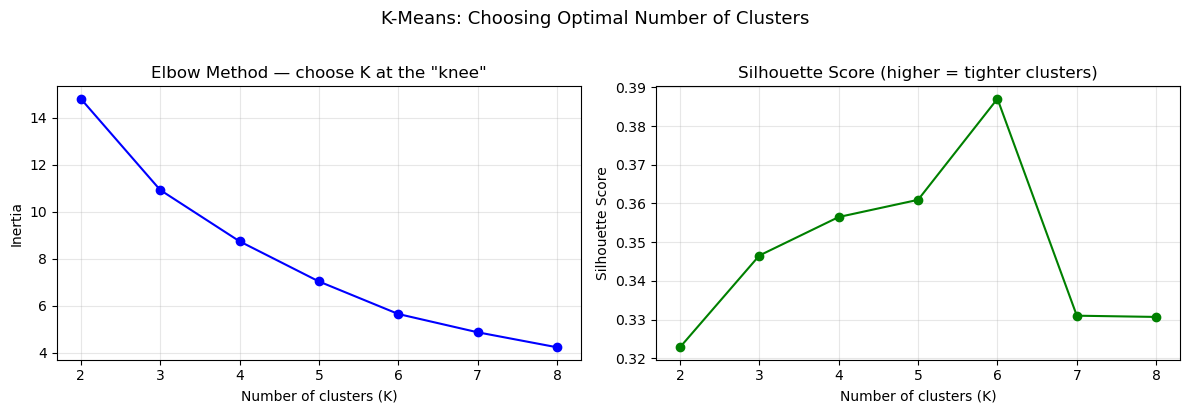


K  | Inertia     | Silhouette
-----------------------------------
2  |     14.803  | 0.3228
3  |     10.923  | 0.3465
4  |      8.740  | 0.3565
5  |      7.033  | 0.3609
6  |      5.649  | 0.3870
7  |      4.872  | 0.3310
8  |      4.234  | 0.3307


In [5]:
# ── Elbow + Silhouette analysis ────────────────────────────────────────────
K_RANGE     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(profiles_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(profiles_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(K_RANGE), inertias, 'bo-', markersize=6)
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method — choose K at the "knee"')
ax1.grid(alpha=0.3)

ax2.plot(list(K_RANGE), silhouettes, 'go-', markersize=6)
ax2.set_xlabel('Number of clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher = tighter clusters)')
ax2.grid(alpha=0.3)

plt.suptitle('K-Means: Choosing Optimal Number of Clusters', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nK  | Inertia     | Silhouette")
print("-" * 35)
for k, iner, sil in zip(K_RANGE, inertias, silhouettes):
    print(f"{k}  | {iner:10.3f}  | {sil:.4f}")

In [6]:
# ── Fit final K-Means ──────────────────────────────────────────────────────
# Set OPTIMAL_K based on the elbow + silhouette plots above.
# Expected: 5 (aligns roughly with Singapore's 5 planning regions)
OPTIMAL_K = 5

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
town_profiles['cluster'] = kmeans.fit_predict(profiles_scaled)

# Print cluster membership with key stats to help interpret each group
print(f"K = {OPTIMAL_K} — Town cluster assignments:\n")
for cid in sorted(town_profiles['cluster'].unique()):
    mask   = town_profiles['cluster'] == cid
    towns  = town_profiles.loc[mask, 'town'].tolist()
    stats  = town_profiles.loc[mask, PROFILE_FEATURES].median()
    print(f"  Cluster {cid} ({len(towns)} towns): {', '.join(towns)}")
    print(f"    Median price: ${stats['resale_price']:,.0f}  |  "
          f"CBD dist: {stats['distance_from_cbd']:.1f} km  |  "
          f"HDB age: {stats['hdb_age']:.0f} yrs  |  "
          f"Liveability: {stats['liveability_index']:.3f}")
    print()

K = 5 — Town cluster assignments:

  Cluster 0 (2 towns): KALLANG/WHAMPOA, MARINE PARADE
    Median price: $509,000  |  CBD dist: 5.5 km  |  HDB age: 46 yrs  |  Liveability: 0.600

  Cluster 1 (8 towns): ANG MO KIO, BEDOK, BISHAN, BUKIT TIMAH, CLEMENTI, GEYLANG, TOA PAYOH, WOODLANDS
    Median price: $440,500  |  CBD dist: 9.4 km  |  HDB age: 42 yrs  |  Liveability: 0.639

  Cluster 2 (4 towns): CHOA CHU KANG, PUNGGOL, SEMBAWANG, SENGKANG
    Median price: $490,000  |  CBD dist: 14.9 km  |  HDB age: 22 yrs  |  Liveability: 0.656

  Cluster 3 (9 towns): BUKIT BATOK, BUKIT PANJANG, HOUGANG, JURONG EAST, JURONG WEST, PASIR RIS, SERANGOON, TAMPINES, YISHUN
    Median price: $465,000  |  CBD dist: 13.4 km  |  HDB age: 37 yrs  |  Liveability: 0.623

  Cluster 4 (3 towns): BUKIT MERAH, CENTRAL AREA, QUEENSTOWN
    Median price: $605,000  |  CBD dist: 3.2 km  |  HDB age: 40 yrs  |  Liveability: 0.644



c:\Users\jared\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [7]:
# ── Name the clusters ──────────────────────────────────────────────────────
# Assign descriptive labels based on the cluster membership printed in Step 5.
# Review the output above and update these names to match the actual run.
CLUSTER_NAMES = {
    0: "City Fringe Premium",
    1: "New Suburban Towns",
    2: "Established Outer Estates",
    3: "Affordable Mature Estates",
    4: "East Coast Heritage",
}

town_profiles['cluster_name'] = town_profiles['cluster'].map(CLUSTER_NAMES)

print("Cluster → Town mapping:")
print(town_profiles[['town', 'cluster', 'cluster_name']]
      .sort_values('cluster')
      .to_string(index=False))

Cluster → Town mapping:
           town  cluster              cluster_name
  MARINE PARADE        0       City Fringe Premium
KALLANG/WHAMPOA        0       City Fringe Premium
     ANG MO KIO        1        New Suburban Towns
          BEDOK        1        New Suburban Towns
        GEYLANG        1        New Suburban Towns
       CLEMENTI        1        New Suburban Towns
         BISHAN        1        New Suburban Towns
    BUKIT TIMAH        1        New Suburban Towns
      WOODLANDS        1        New Suburban Towns
      TOA PAYOH        1        New Suburban Towns
  CHOA CHU KANG        2 Established Outer Estates
       SENGKANG        2 Established Outer Estates
        PUNGGOL        2 Established Outer Estates
      SEMBAWANG        2 Established Outer Estates
  BUKIT PANJANG        3 Affordable Mature Estates
        HOUGANG        3 Affordable Mature Estates
         YISHUN        3 Affordable Mature Estates
      SERANGOON        3 Affordable Mature Estates
    JUR

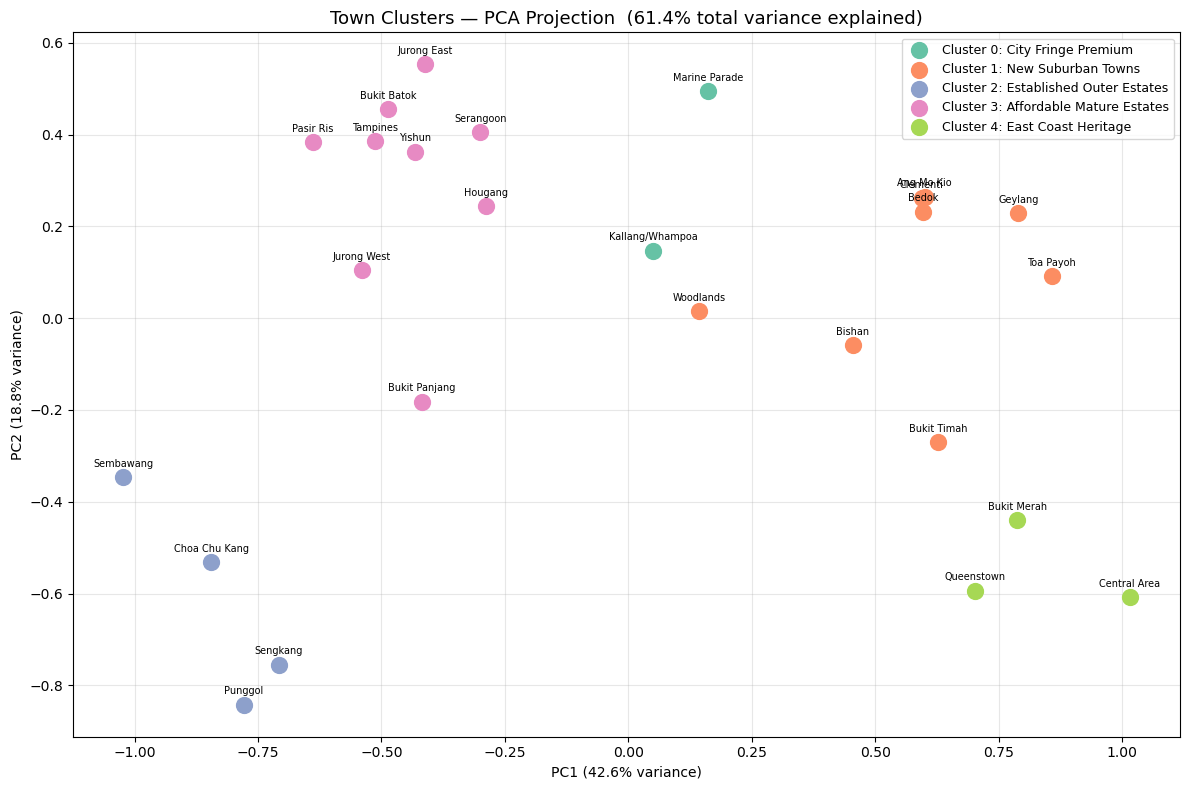

In [8]:
# ── PCA visualisation (2D projection of 12-feature town profile space) ─────
pca        = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(profiles_scaled)
palette    = sns.color_palette('Set2', OPTIMAL_K)

fig, ax = plt.subplots(figsize=(12, 8))

for cid in sorted(town_profiles['cluster'].unique()):
    mask = town_profiles['cluster'] == cid
    ax.scatter(
        pca_coords[mask, 0], pca_coords[mask, 1],
        color=palette[cid], s=130, zorder=2,
        label=f"Cluster {cid}: {CLUSTER_NAMES[cid]}"
    )

# Label each dot with the town name
for i, row in town_profiles.iterrows():
    ax.annotate(
        row['town'].title(),
        (pca_coords[i, 0], pca_coords[i, 1]),
        fontsize=7, ha='center', va='bottom',
        xytext=(0, 6), textcoords='offset points'
    )

var_explained = pca.explained_variance_ratio_.sum() * 100
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title(
    f"Town Clusters — PCA Projection  "
    f"({var_explained:.1f}% total variance explained)",
    fontsize=13
)
ax.legend(loc='upper right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# ── Propagate cluster labels to every transaction in df ───────────────────
town_to_cluster      = dict(zip(town_profiles['town'], town_profiles['cluster']))
df['cluster_label']  = df['town'].map(town_to_cluster)

print("Cluster distribution in full dataset:")
cluster_counts = df['cluster_label'].value_counts().sort_index()
for cid, cnt in cluster_counts.items():
    name = CLUSTER_NAMES[cid]
    print(f"  Cluster {cid} ({name}): {cnt:,} transactions ({cnt/len(df)*100:.1f}%)")

Cluster distribution in full dataset:
  Cluster 0 (City Fringe Premium): 9,948 transactions (3.7%)
  Cluster 1 (New Suburban Towns): 73,602 transactions (27.2%)
  Cluster 2 (Established Outer Estates): 57,831 transactions (21.4%)
  Cluster 3 (Affordable Mature Estates): 109,391 transactions (40.4%)
  Cluster 4 (East Coast Heritage): 19,847 transactions (7.3%)


---

## Step 6: Feature Selection for Supervised Classifier

Features must be:
1. **Interpretable** — the buyer can state a preference in these terms
2. **Reconstructible at inference** — the app can derive the value from form inputs

`distance_from_cbd` replaces `age_location_score` as the location signal — it is direct
and unambiguous (no interaction term masking the effect).

`pri_sch_nearest_distance` is included as the 10th feature — school access is a
meaningful differentiator between clusters (central/mature areas have denser school
coverage) and maps cleanly to a "Near School" toggle at inference.

`liveability_index` is excluded from the classifier (used only in town profiles): it is a
complex composite that cannot be accurately reconstructed from form checkboxes.

In [29]:
# 12 buyer-interpretable features — each maps directly to a form input in the web app
# The 3 amenity_cluster tiers are added alongside individual distances for testing.
# At inference, tiers are derived from the same distances: e.g. mrt < 500 → +1 to 500m tier.
# estate_height_modernity disambiguates tall-new vs tall-old estates (e.g. Punggol vs Queenstown).
# block_diversity: Shannon entropy of flat-type mix — proxy for estate character variety.
CLASSIFIER_FEATURES = [
    'resale_price',               # budget
    'floor_area_sqm',             # flat size
    'block_diversity',            # flat-type mix (Shannon entropy) — estate character
    'mrt_nearest_distance',       # MRT access (form: Near MRT toggle → 500m or 1500m)
    'Hawker_Nearest_Distance',    # hawker access (form: Near Hawker toggle → 300m or 1000m)
    'Mall_Nearest_Distance',      # mall access (form: Near Mall toggle → 500m or 1500m)
    'pri_sch_nearest_distance',   # school access (form: Near School toggle → 500m or 1500m)
    'storey_ratio',               # floor preference
    'estate_height_modernity',    # max_floor_lvl / (hdb_age + 1) — tall-new vs tall-old
    'amenity_cluster_500m',       # amenity types within 500m (walking)
    'amenity_cluster_1km',        # amenity types within 1km (short walk/bus)
    'amenity_cluster_2km',        # amenity types within 2km (neighbourhood)
]
TARGET = 'cluster_label'

X = df[CLASSIFIER_FEATURES].copy()
y = df[TARGET].copy()

# Drop rows with nulls in any feature or target
valid_mask = X.notna().all(axis=1) & y.notna()
X, y = X[valid_mask], y[valid_mask]

print(f"Dataset: {X.shape[0]:,} transactions x {X.shape[1]} features")
print(f"Target classes: {sorted(y.unique())} ({y.nunique()} clusters)")
print()
display(X.describe().round(2))

Dataset: 265,409 transactions x 12 features
Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] (5 clusters)



,resale_price,floor_area_sqm,block_diversity,mrt_nearest_distance,Hawker_Nearest_Distance,Mall_Nearest_Distance,pri_sch_nearest_distance,storey_ratio,estate_height_modernity,amenity_cluster_500m,amenity_cluster_1km,amenity_cluster_2km
count,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00,265409.00
mean,505340.59,96.78,0.67,701.52,1162.51,662.99,409.60,0.56,0.75,1.82,3.21,3.80
std,175092.98,24.29,0.47,415.26,1067.46,365.32,246.34,0.28,0.80,1.00,0.75,0.42
min,150000.00,31.00,-0.00,21.97,1.87,0.00,42.55,0.04,0.03,0.00,0.00,1.00
25%,377400.00,75.00,0.07,399.40,377.83,392.78,232.04,0.33,0.29,1.00,3.00,4.00
50%,470000.00,93.00,0.86,628.18,780.74,602.13,360.24,0.53,0.42,2.00,3.00,4.00
75%,600000.00,112.00,0.98,906.70,1636.07,870.01,523.93,0.80,0.86,2.00,4.00,4.00
max,1658888.00,366.70,1.98,3544.50,4816.06,3496.40,3306.00,1.50,8.00,4.00,4.00,4.00


---

## Step 7: Train / Test Split, SMOTE, and Scaling

In [30]:
# Stratified split preserves cluster proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

# SMOTE on training set only — balances cluster class sizes without touching test data
sm = SMOTE(random_state=RANDOM_STATE)
X_train, y_train = sm.fit_resample(X_train, y_train)
print(f"After SMOTE — Train: {X_train.shape[0]:,}")

unique, counts = np.unique(y_train, return_counts=True)
print("Class distribution after SMOTE:", dict(zip(unique.tolist(), counts.tolist())))

# StandardScaler fitted on training data only (prevents data leakage to test set)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

Train: 199,056  |  Test: 66,353
After SMOTE — Train: 407,175
Class distribution after SMOTE: {0: 81435, 1: 81435, 2: 81435, 3: 81435, 4: 81435}


---

## Step 8: Train and Compare Models

All models trained on the same scaled data. Results compared on:
- **Test Accuracy** — primary metric
- **Generalization Gap** — Train Acc − Test Acc (lower = less overfitting)
- **Runtime** — training time in seconds

Selection rule: within 0.01 of best test accuracy, pick the model with lowest runtime
(same rule used in `manyu_-_Classification_Models_Comparison.ipynb`).

In [31]:
# ── Evaluation helper (reused from manyu_-_Classification_Models_Comparison.ipynb) ──
def evaluate_classification_model(
    model, X_train_data, X_test_data,
    y_train_data, y_test_data,
    model_name, feature_columns
):
    """Fit model, compute accuracy metrics, extract feature importances."""
    start   = time.perf_counter()
    model.fit(X_train_data, y_train_data)
    runtime = time.perf_counter() - start

    train_pred = model.predict(X_train_data)
    test_pred  = model.predict(X_test_data)

    # CatBoost returns object arrays — coerce to int
    if CatBoostClassifier is not None and isinstance(model, CatBoostClassifier):
        train_pred = np.array(train_pred).astype(int).ravel()
        test_pred  = np.array(test_pred).astype(int).ravel()

    train_acc = accuracy_score(y_train_data, train_pred)
    test_acc  = accuracy_score(y_test_data,  test_pred)

    # Feature importances for tree-based; mean absolute coefficients for linear
    if hasattr(model, 'feature_importances_'):
        imp_vals = model.feature_importances_
    elif hasattr(model, 'coef_'):
        coef     = model.coef_
        imp_vals = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
    else:
        imp_vals = np.zeros(len(feature_columns))

    importance_df = pd.DataFrame({
        'Feature':    feature_columns,
        'Importance': imp_vals,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)

    return {
        'Model':              model_name,
        'Train Accuracy':     train_acc,
        'Test Accuracy':      test_acc,
        'Generalization Gap': train_acc - test_acc,
        'Runtime (sec)':      runtime,
        'Feature Importance': importance_df,
        'fitted_model':       model,
    }

In [32]:
# ── Train all models ───────────────────────────────────────────────────────
results = []

# Logistic Regression — linear baseline
lr_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
results.append(evaluate_classification_model(
    lr_model, X_train_sc, X_test_sc, y_train, y_test,
    'Logistic Regression', CLASSIFIER_FEATURES
))
print(f"Logistic Regression done  — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1
)
results.append(evaluate_classification_model(
    rf_model, X_train_sc, X_test_sc, y_train, y_test,
    'Random Forest', CLASSIFIER_FEATURES
))
print(f"Random Forest done        — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# LightGBM
if LGBMClassifier is not None:
    lgbm_model = LGBMClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05,
        num_leaves=31, random_state=RANDOM_STATE, verbosity=-1
    )
    results.append(evaluate_classification_model(
        lgbm_model, X_train_sc, X_test_sc, y_train, y_test,
        'LightGBM', CLASSIFIER_FEATURES
    ))
    print(f"LightGBM done             — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# XGBoost
if XGBClassifier is not None:
    xgb_model = XGBClassifier(
        n_estimators=N_ESTIMATORS, learning_rate=0.05,
        random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
    )
    results.append(evaluate_classification_model(
        xgb_model, X_train_sc, X_test_sc, y_train, y_test,
        'XGBoost', CLASSIFIER_FEATURES
    ))
    print(f"XGBoost done              — Test Acc: {results[-1]['Test Accuracy']:.4f}")

# CatBoost
if CatBoostClassifier is not None:
    cb_model = CatBoostClassifier(
        iterations=N_ESTIMATORS, learning_rate=0.05,
        random_state=RANDOM_STATE, verbose=0
    )
    results.append(evaluate_classification_model(
        cb_model, X_train_sc, X_test_sc, y_train, y_test,
        'CatBoost', CLASSIFIER_FEATURES
    ))
    print(f"CatBoost done             — Test Acc: {results[-1]['Test Accuracy']:.4f}")

print(f"\n{len(results)} models trained.")

Logistic Regression done  — Test Acc: 0.6063
Random Forest done        — Test Acc: 0.9996


c:\Users\jared\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\jared\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM done             — Test Acc: 0.9775
XGBoost done              — Test Acc: 0.9411
CatBoost done             — Test Acc: 0.8612

5 models trained.


In [33]:
# ── Comparison table + model selection ────────────────────────────────────
comparison_df = pd.DataFrame([{
    'Model':              r['Model'],
    'Train Accuracy':     round(r['Train Accuracy'],     4),
    'Test Accuracy':      round(r['Test Accuracy'],      4),
    'Generalization Gap': round(r['Generalization Gap'], 4),
    'Runtime (sec)':      round(r['Runtime (sec)'],      2),
} for r in results]).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

display(comparison_df)

# Select recommended model: within 0.05 of best, pick fastest
ACCURACY_TOLERANCE = 0.05
best_test   = comparison_df['Test Accuracy'].max()
candidates  = comparison_df[
    comparison_df['Test Accuracy'] >= best_test - ACCURACY_TOLERANCE
].sort_values(['Runtime (sec)', 'Generalization Gap']).reset_index(drop=True)

recommended_name   = candidates.iloc[0]['Model']
recommended_row    = candidates.iloc[0]
recommended_result = next(r for r in results if r['Model'] == recommended_name)

print(f"\n★ Recommended model: {recommended_name}")
print(f"  Test accuracy:      {recommended_row['Test Accuracy']:.4f} "
      f"({recommended_row['Test Accuracy']*100:.2f}%)")
print(f"  Generalization gap: {recommended_row['Generalization Gap']:.4f}")
print(f"  Runtime:            {recommended_row['Runtime (sec)']:.2f}s")

,Model,Train Accuracy,Test Accuracy,Generalization Gap,Runtime (sec)
0,Random Forest,1.0000,0.9996,0.0004,52.59
1,LightGBM,0.9690,0.9775,-0.0085,10.94
2,XGBoost,0.9360,0.9411,-0.0051,17.76
3,CatBoost,0.8792,0.8612,0.0180,27.65
4,Logistic Regression,0.6337,0.6063,0.0274,4.19



★ Recommended model: LightGBM
  Test accuracy:      0.9775 (97.75%)
  Generalization gap: -0.0085
  Runtime:            10.94s


---

## Step 9: Feature Importance

Which features most strongly determine cluster membership? These are the dimensions
buyers should consider most carefully when choosing a town type.

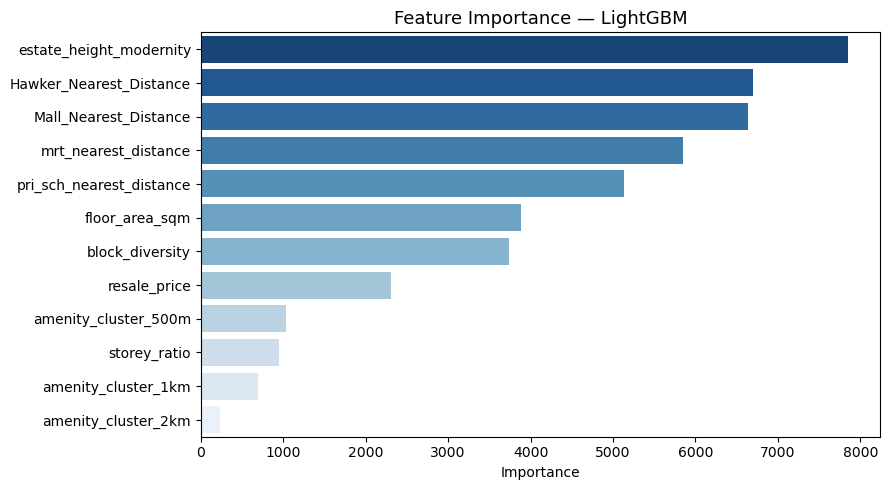


Feature importances (ranked):
                 Feature  Importance
 estate_height_modernity        7846
 Hawker_Nearest_Distance        6697
   Mall_Nearest_Distance        6636
    mrt_nearest_distance        5851
pri_sch_nearest_distance        5136
          floor_area_sqm        3887
         block_diversity        3738
            resale_price        2303
    amenity_cluster_500m        1038
            storey_ratio         949
     amenity_cluster_1km         692
     amenity_cluster_2km         227


In [34]:
importance_df = recommended_result['Feature Importance']

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=importance_df,
    x='Importance', y='Feature',
    palette='Blues_r', ax=ax
)
ax.set_title(f'Feature Importance — {recommended_name}', fontsize=13)
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print("\nFeature importances (ranked):")
print(importance_df.to_string(index=False))

---

## Step 10: Export Artifacts

Saves all files needed by `app/app.py` to serve recommendations.

| File | Purpose |
|---|---|
| `lgbm_classifier.joblib` | Trained classifier (predict cluster from buyer features) |
| `scaler_classifier.joblib` | StandardScaler — must be applied before prediction |
| `cluster_labels.json` | Cluster ID → descriptive name (e.g. "Mature Central") |
| `town_cluster_map.json` | Town → cluster ID (for returning towns within predicted cluster) |
| `classifier_feature_columns.json` | Feature order — `app.py` must build its array in this exact order |

In [35]:
MODEL_DIR = Path("../app/models")
MODEL_DIR.mkdir(exist_ok=True)

best_model = recommended_result['fitted_model']

# 1. Classifier — saved as lgbm_classifier.joblib regardless of which model won
#    (app.py loads this single filename)
joblib.dump(best_model, MODEL_DIR / "lgbm_classifier.joblib")
print(f"Saved: lgbm_classifier.joblib  (model type: {type(best_model).__name__})")

# 2. Scaler — must be applied at inference (model trained on scaled features)
joblib.dump(scaler, MODEL_DIR / "scaler_classifier.joblib")
print("Saved: scaler_classifier.joblib")

# 3. K-Means clusterer and profile scaler — saved for reproducibility
joblib.dump(kmeans, MODEL_DIR / "kmeans_town_clusterer.joblib")
joblib.dump(profile_scaler, MODEL_DIR / "profile_scaler.joblib")
print("Saved: kmeans_town_clusterer.joblib")
print("Saved: profile_scaler.joblib")

# 4. Cluster descriptions — displayed in the app recommendation output
cluster_descriptions = {str(k): v for k, v in CLUSTER_NAMES.items()}
with open(MODEL_DIR / "cluster_labels.json", "w") as f:
    json.dump(cluster_descriptions, f, indent=2)
print(f"Saved: cluster_labels.json  ({len(cluster_descriptions)} clusters)")

# 5. Town → cluster map — app uses this to return towns within the predicted cluster
town_cluster_map = dict(zip(town_profiles['town'], town_profiles['cluster'].astype(int)))
with open(MODEL_DIR / "town_cluster_map.json", "w") as f:
    json.dump(town_cluster_map, f, indent=2)
print(f"Saved: town_cluster_map.json  ({len(town_cluster_map)} towns)")

# 6. Feature column order — app.py must build its input array in exactly this order
with open(MODEL_DIR / "classifier_feature_columns.json", "w") as f:
    json.dump(CLASSIFIER_FEATURES, f, indent=2)
print(f"Saved: classifier_feature_columns.json  ({len(CLASSIFIER_FEATURES)} features)")

# 7. Town profiles — per-town median of CLASSIFIER_FEATURES for inference-time similarity scoring
#    app.py scales these at startup using the saved scaler, then computes L2 distance
#    between each town's profile and the buyer's input vector to rank towns within a cluster
town_clf_profiles = df.groupby('town')[CLASSIFIER_FEATURES].median()
town_profiles_dict = town_clf_profiles.to_dict(orient='index')
with open(MODEL_DIR / "town_profiles.json", "w") as f:
    json.dump(town_profiles_dict, f, indent=2)
print(f"Saved: town_profiles.json  ({len(town_profiles_dict)} towns x {len(CLASSIFIER_FEATURES)} features)")

print("\nAll artifacts saved. Update and restart app/app.py to serve recommendations.")

Saved: lgbm_classifier.joblib  (model type: LGBMClassifier)
Saved: scaler_classifier.joblib
Saved: kmeans_town_clusterer.joblib
Saved: profile_scaler.joblib
Saved: cluster_labels.json  (5 clusters)
Saved: town_cluster_map.json  (26 towns)
Saved: classifier_feature_columns.json  (12 features)
Saved: town_profiles.json  (26 towns x 12 features)

All artifacts saved. Update and restart app/app.py to serve recommendations.
